# Pendolo fisico
Giovanni Nicola D'Aloisio, n. di matricola 494722; prova svolta il 14 aprile 2021.

---

## Introduzione
<p align="justify">Un pendolo semplice è una massa libera di oscillare attorno a un punto fisso, al quale è vincolato mediante una corda tesa, e soggetto alla sola forza di gravità. Se la massa viene rilasciata con un certo angolo rispetto alla verticale, questa cade e quindi risale con un certo periodo $T$, se si considera trascurabile il fattore di attrito viscoso dell'aria. Dunque la posizione di un pendolo è, per piccoli intervalli di tempo e piccole ampiezze, descritta da un moto armonico semplice. In tali ipotesi si può determinare con elevata precisione la pulsazione dal best-ﬁt dei dati sperimentali e quindi quantificare il valore dell'accelerazione gravitazionale terrestre e l'intervallo di validità dell'approssimazione armonica.

## Scopi della prova

Gli obiettivi di questa prova sono:
* Verificare la legge di dipendenza del periodo del pendolo fisico dall’ampiezza di oscillazione;
* Determinare l’intervallo di validità dell’approssimazione armonica;
* Determinare l'accelerazione di gravità $g$ nel limite di ampiezza di oscillazione tendente a zero.

## Apparato sperimentale

Per raggiungere gli obiettivi della prova si dispone di:
* Un filo inestensibile di nylon avente massa trascurabile;
* Una massa sferica di massa nota;
* Un calibro, per misurare il raggio della massa;
* Un metro, per misurare la lunghezza del filo;
* Un sostegno orizzontale sopraelevato, per sostenere il sistema filo-massa;
* Un sensore di moto, per rilevare la posizione della sfera nel tempo.

## Procedura

<p align="justify">Nella prima parte della prova si pone il pendolo in oscillazione da una decina di valori differenti di ampiezza non troppo elevata e, tramite il sensore di moto, se ne traccia la posizione nel tempo per 10 secondi; eseguendo il best-fit dei dati sperimentali secondo la legge:

> $x(t)=A e^{- \gamma t} \sin (\omega t + \varphi) + x_0$

<p align="justify">si ottengono i parametri del moto armonico studiato. Se si verifica la relazione:

> $\omega_0 - \sqrt{L \over g} \leq \delta \omega_s$

<p align="justify">dove $L \pm \delta L$ è la lunghezza del pendolo e $g$ è l'accelerazione gravitazionale, allora il pendolo fisico può essere approssimato con un pendolo semplice.

<p align="justify">Nella seconda parte della prova vengono utilizzati i parametri di fit per valutare il periodo e l'angolo di oscillazione di ciascuna prova:

> $T = {2 \pi \over \omega_s} \quad \quad \vartheta_0 = \arcsin {A \over L}$

<p align="justify">Sapendo che il periodo del pendolo è legato all'angolo di oscillazione dalla relazione:

> $T=T_0 \Big( 1 + \frac{1}{4} \sin^2{\vartheta_0 \over 2} +\frac{9}{64} \sin^4{\vartheta_0 \over 2} + \dots \Big)$

<p align="justify">Si può calcolare il valore di $T_0 \pm \delta T_0$ come punto di intersezione della curva di equazione $T(\vartheta_0)$ sopra esposta. Con quest'ultimo si può l'intervallo di validità dell'approssimazione armonica, sapendo che:

> ${T - T_0 \over T_0} \leq {\delta T_\text{exp} \over T_\text{exp}} \quad \Rightarrow \quad {1 \over 4} \sin^2{\vartheta_0 \over 2} \leq {\delta T_\text{exp} \over T_\text{exp}}$

<p align="justify">e che quindi deve essere:

> $\vartheta_0 \leq 2 \arcsin \Big( 2 \sqrt{\delta T_\text{exp} \over T_\text{exp}}\Big)$

<p align="justify">Nella terza parte della prova si risale al valore dell'accelerazione di gravità $g \pm \delta g$ usando il valore di $T_0 \pm \delta T_0$ precedentemente calcolato. Infatti:

> $T_0 = 2 \pi \sqrt{L \over g} \quad \Rightarrow \quad g = 4 \pi^2 {L \over T_0^2}$

## Analisi dei dati sperimentali
In questa sezione sono riportati gli script in Python utilizzati per l'analisi dei dati sperimentali, con i relativi risultati.

In [1]:
# Da importare all'inizio

import numpy as np  
from matplotlib import pyplot as plt 
from scipy.optimize import curve_fit
from scipy import odr, constants

### Dipendenza del periodo dall’ampiezza di oscillazione

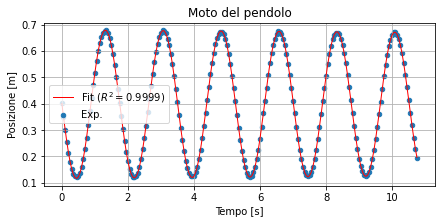

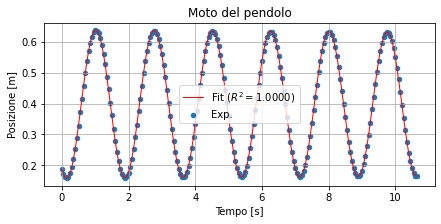

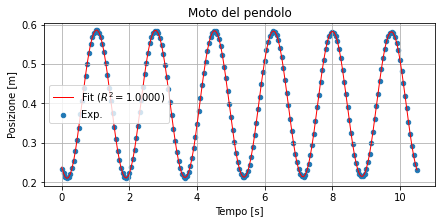

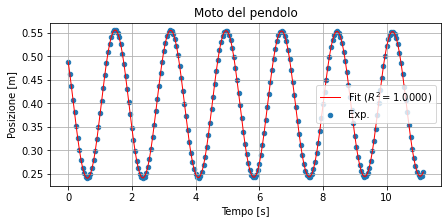

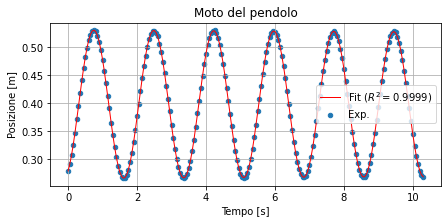

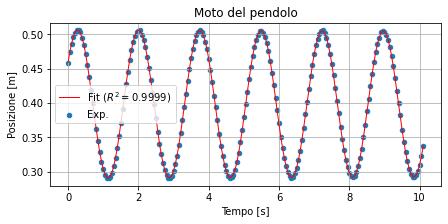

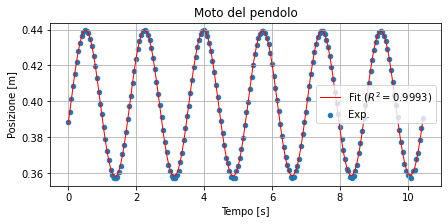

Pendolo fisico non approssimabile a pendolo semplice
Pendolo fisico non approssimabile a pendolo semplice
Pendolo fisico non approssimabile a pendolo semplice
Pendolo fisico non approssimabile a pendolo semplice
Pendolo fisico non approssimabile a pendolo semplice
Pendolo fisico non approssimabile a pendolo semplice
Pendolo fisico non approssimabile a pendolo semplice


In [2]:
# Dati grezzi (S.I.)

L	= 0.750         # Lunghezza pendolo
L_err = 0.001     # Errore su lunghezza pendolo
d = 0.048         # Diametro sfera
d_err = 50e-6     # Errore su diametro sfera

# Aggiungere alla lista per vedere anche l'oscillazione lunga non armonica: 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/ccda2c6e11c4a9657eef415c937f5ec6ca9a3a6a/Lab_210414%20-%20Pendolo/Moto_smorzato.txt'

hub_data = ['https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210414%20-%20Pendolo/Prove_ripetute/Run2.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210414%20-%20Pendolo/Prove_ripetute/Run3.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210414%20-%20Pendolo/Prove_ripetute/Run4.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210414%20-%20Pendolo/Prove_ripetute/Run5.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210414%20-%20Pendolo/Prove_ripetute/Run6.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210414%20-%20Pendolo/Prove_ripetute/Run7.txt', 'https://raw.githubusercontent.com/nikitodos/Laboratorio1/main/Lab_210414%20-%20Pendolo/Prove_ripetute/Run8.txt']

fit_params = []

for url in hub_data:

  # Importazione dati per il fit

  dati = np.loadtxt(url, dtype=np.str, delimiter="\t", skiprows=1)
  dati = np.char.replace(dati, ',', '.')
  dati = dati[:,0:2]
  dati = dati.astype(np.float)

  t=dati[:,0]
  y=dati[:,1]

  # Definizione della funzione di fit

  def damped_sine(t, A, omega, phi, gamma, y0): 
    return A*np.exp(-gamma*t)*np.sin(omega*t+phi)+y0

  # Fitting routine
  
  def fitplot_sin(A, omega, y0, phi, gamma, print_output=True, plot_guess=False):
  
    guess = np.array([A,omega,phi,gamma,y0])
    bounds = ([0,0,-np.pi,0,0], [10., 10, np.pi,1,2]) 
  
    global popt, pcov
  
    popt, pcov = curve_fit(damped_sine, t, y, p0=guess, bounds=bounds)

    # Calcolo il coefficiente R2 per valutare la bontà del fit

    residuals = y- damped_sine(t,popt[0],popt[1],popt[2],popt[3],popt[4])
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)

    # Plot dei risultati

    plt.figure(figsize=(7, 3))

    if plot_guess:
      plt.plot(t, damped_sine(t, guess[0], guess[1], guess[2],guess[3],guess[4]),'--', color=[0.3,0.7,0], label="Guess", linewidth=2)
    
    plt.scatter(t,y,s=20,label="Exp.")     
    plt.plot(t,damped_sine(t,popt[0],popt[1],popt[2],popt[3],popt[4]),color=[1,0,0],label="Fit ($R^2=${:.4f})".format(r_squared),linewidth=1)
    plt.title("Moto del pendolo")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Posizione [m]")
    plt.grid(which='both')
    plt.legend()
    plt.show()
    
    # Esportazione parametri dei fit
    # Lista del tipo [[A, dA], [ω, dω], [ϕ, dϕ], [γ, dγ], [R, 0]]

    parametri = []

    for v, e in zip(popt, np.sqrt(np.diag(pcov))):
      parametri.append([abs(v),abs(e)])
    
    parametri.append([r_squared, 0])

    fit_params.append(parametri)

  fitplot_sin(5, 5, 0, 0, 0)

fit_params = np.array(fit_params)

# Stampa una scritta se il pendolo non e` approssimabile

for i in fit_params:
  if ((i[1])[0] - np.sqrt(L/constants.g) >= (i[1])[1]):
    print("Pendolo fisico non approssimabile a pendolo semplice")

# print(fit_params)                 # Scommentare per vedere i parametri del fit

### Validità dell'approssimazione armonica e calcolo di $g$ per $A \rightarrow 0$

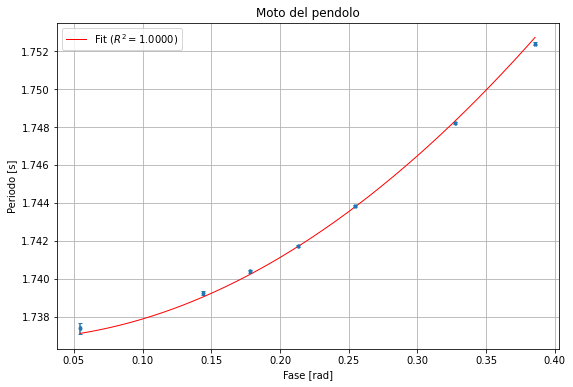

	 T₀ = 1.7368 +/- 0.0001
	 R² = 0.9999984432558754
	 |ϑ₀| ≤ 1.3294°
	 g  = 9.8159 +/- 0.0137


In [3]:
# Importazione dati per il fit (S.I.)

data = []

for i in fit_params:
  data.append([np.arcsin((i[0])[0]/L), (2*np.pi)/((i[1])[0]), (1/(L*np.sqrt(1-((i[0])[0]/L)**2)))*(i[0])[1] + ((i[0])[0]/(L**2*np.sqrt(1-((i[0])[0]/L)**2)))*L_err, (2*(i[1])[1]*np.pi)/(i[1])[0]**2])  # Calcolo ϕ usando A

data = np.array(data)

theta = []

for i in data:
  theta.append(i[0])

theta = np.array(theta)

T = []

for i in data:
  T.append(i[1])

T = np.array(T)

theta_err = []

for i in data:
  theta_err.append(i[2])

theta_err = np.array(theta_err)

T_err = []

for i in data:
  T_err.append(i[3])

T_err = np.array(T_err)

# Definizione della funzione di fit

def sin2(T0,theta): 
  return T0*(1+0.25*(np.sin(theta/2))**2)

# Fitting routine

def fitplot_period(T0, print_output=True, plot_guess=False):

  sin2_model = odr.Model(sin2)
  fit_data = odr.RealData(theta, T, sx=theta_err, sy=T_err)
  beta0 = np.array([T0])
  
  fit = odr.ODR(fit_data, sin2_model, beta0=beta0)
  global out
  out = fit.run()
    
  # Calcolo il coefficiente R2 per valutare la bontà del fit
  
  residuals = T - sin2(out.beta,theta)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((y-np.mean(y))**2)
  r_squared = 1 - (ss_res / ss_tot)
  
  # Plot dei risultati

  sample_theta = np.linspace(np.amin(theta),np.amax(theta),1000)
  plt.show()
 
  plt.figure(figsize = (9, 6))

  if plot_guess:
    plt.plot(sample_theta, sin2(beta0, sample_theta),'--', color=[0.3,0.7,0], label = "Guess", linewidth=2)
  
  plt.errorbar(theta, T,xerr=theta_err ,yerr=T_err ,linestyle='None', capsize=2, marker='.')
  plt.plot(sample_theta, sin2(out.beta,sample_theta), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.title("Moto del pendolo")
  plt.xlabel("Fase [rad]")
  plt.ylabel("Periodo [s]")
  plt.grid(which='both')
  plt.legend()
  plt.show()
  
  # Stampa parametri di fit, accelerazione gravitazionale, intervallo approssimazione armonica

  if print_output:
    print("\t T₀ = {:0.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
    print("\t R² = " + str(r_squared))
    print("\t |ϑ₀| ≤ {:0.4f}°".format((2*np.arcsin(2*np.sqrt(out.sd_beta[0]/out.beta[0])))*180/constants.pi))
    print("\t g  = {:0.4f} +/- {:2.4f}".format((4*np.pi**2)*(L/(out.beta[0]**2)), (4*np.pi**2/out.beta[0]**2)*(L_err) + (8*np.pi**2*L/out.beta[0]**3)*out.sd_beta[0]))

fitplot_period(2)

## Discussione dei risultati e conclusioni

<p align="justify">Dall'analisi dei dati sperimentali risulta che in nessuna delle prove eseguite il pendolo fisico può essere approssimato con quello semplice, verificando la dipendenza del periodo dalla particolare ampiezza scelta.

<p align="justify">Inoltre l'approssimazione armonica si verifica solo per angoli di inclinazione minori di:

> $\vartheta \leq 1.3294°$

<p align="justify">Effettivamente ci si aspettava un valore compreso tra 1° e 2°, per cui viene accettato.

<p align="justify">Infine, dal valore di $T_0$ risulta:

> $g_\text{ Pavia}  = 9.8159 \pm 0.0137 \text{ m/s}$

<p align="justify">Un risultato compatibile con quello tabulato ($g_\text{ Pavia} = 9.805 \text{ m s}^{-2}$), per cui viene considerato anch'esso corretto.

<p align="justify">Per i risultati ottenuti, si considerano allora raggiunti tutti gli obiettivi della prova.